# SPADE Pipeline Exploration Notebook

This notebook breaks down the entire SPADE pipeline into explorable cells:
- Data loading and visualization
- Synthetic anomaly generation (80/20 normal/synthetic split)
- Comparison: synthetic vs real test anomalies
- Training data preparation
- Model inference and heatmap visualization
- Patch-level label analysis


## 1. Setup and Imports


In [1]:
import sys
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import yaml
import cv2
from torch.utils.data import DataLoader

from data.mvtec_dataset import MVTecDataset
from data.synthetic import cutpaste, crack_anomaly, mask_to_patch_labels, get_methods_for_category
from utils.heatmap import patches_to_heatmap, overlay_heatmap
from models.spade import SPADE

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


/home/owais/miniconda3/envs/myn_again/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Load Configuration


In [2]:
# Load all configs
config_dir = Path.cwd().parent / "config"

with open(config_dir / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)
with open(config_dir / "model.yaml") as f:
    model_cfg = yaml.safe_load(f)
with open(config_dir / "train.yaml") as f:
    train_cfg = yaml.safe_load(f)

category = data_cfg["dataset"]["category"]
root = data_cfg["dataset"]["root"]
image_size = data_cfg["dataset"]["image_size"]
patch_size = model_cfg["vit"]["patch_size"]
synthetic_prob = data_cfg["synthetic"]["synthetic_prob"]

# Resolve relative paths
project_root = Path.cwd().parent
if not Path(root).is_absolute():
    root = str(project_root / root)

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Category: {category}")
print(f"Dataset root: {root}")
print(f"Image size: {image_size}x{image_size}")
print(f"Patch size: {patch_size}x{patch_size}")
print(f"Number of patches: {(image_size // patch_size) ** 2}")
print(f"Synthetic probability: {synthetic_prob} ({100*(1-synthetic_prob):.0f}% normal, {100*synthetic_prob:.0f}% synthetic)")
print(f"\nHPA Configuration:")
print(f"  n_max: {model_cfg['hpa']['n_max']} (starting patches)")
print(f"  n_min: {model_cfg['hpa']['n_min']} (final patches)")
print(f"  t_steps: {model_cfg['hpa']['t_steps']} (refinement steps)")
print(f"\nScoring Configuration:")
print(f"  alpha (attention): {model_cfg['scoring']['alpha']}")
print(f"  beta (Mahalanobis): {model_cfg['scoring']['beta']}")
print(f"  gamma (amplification): {model_cfg['scoring']['mahalanobis_gamma']}")
print("=" * 60)


CONFIGURATION
Category: screw
Dataset root: /home/owais/spade/datasets/mvtec_anomaly_detection
Image size: 224x224
Patch size: 14x14
Number of patches: 256
Synthetic probability: 0.2 (80% normal, 20% synthetic)

HPA Configuration:
  n_max: 256 (starting patches)
  n_min: 32 (final patches)
  t_steps: 8 (refinement steps)

Scoring Configuration:
  alpha (attention): 0.4
  beta (Mahalanobis): 0.4
  gamma (amplification): 1.3


## 3. Load Training Data (Normal Images)


In [3]:
# Load normal training images (no synthetic anomalies)
train_dataset_normal = MVTecDataset(
    root=root,
    category=category,
    split="train",
    image_size=image_size,
    patch_size=patch_size,
    synthetic_method=None,  # No synthetic anomalies
    synthetic_prob=0.0,
)

print(f"Total normal training images: {len(train_dataset_normal)}")

Total normal training images: 320


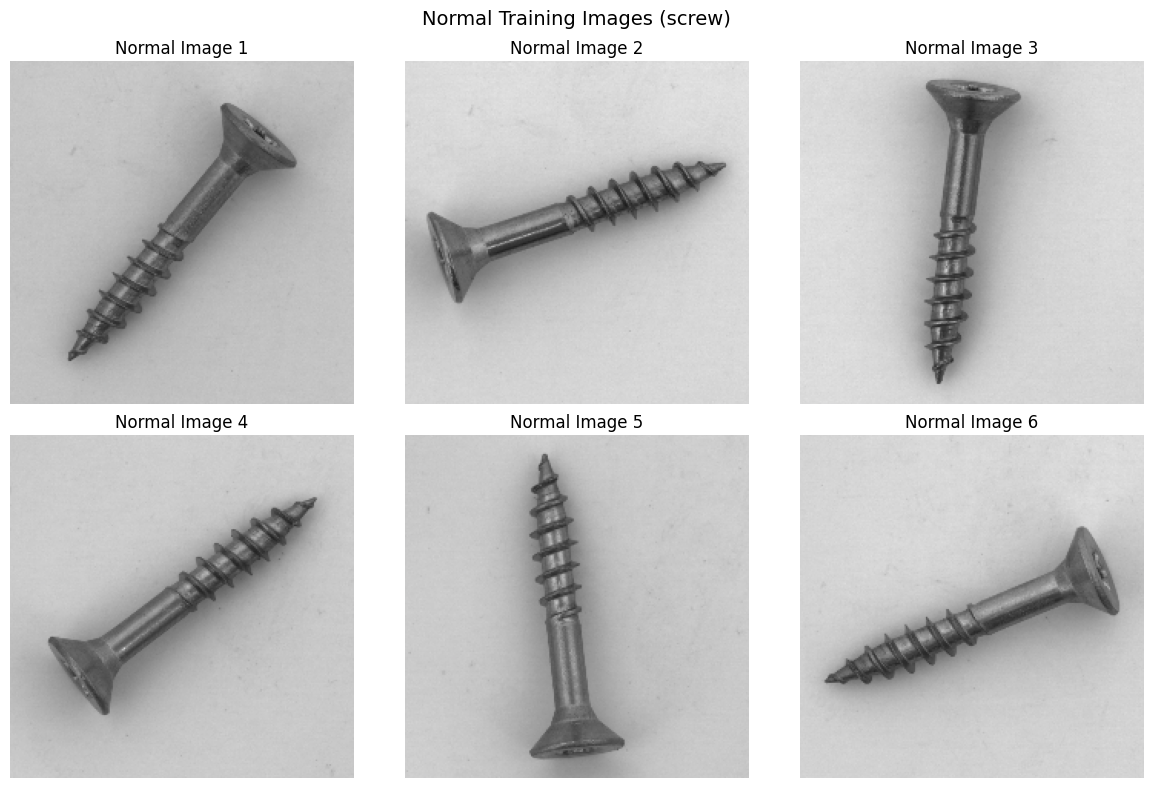

In [4]:
def denormalize_image(image_tensor):
    """Denormalize CLIP-normalized image tensor for visualization."""
    mean = np.array([0.48145466, 0.4578275, 0.40821073])
    std = np.array([0.26862954, 0.26130258, 0.27577711])
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = image_np * std + mean
    return np.clip(image_np, 0, 1)

# Visualize normal images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(min(6, len(train_dataset_normal))):
    sample = train_dataset_normal[i]
    image_np = denormalize_image(sample["image"])
    
    axes[i].imshow(image_np)
    axes[i].set_title(f"Normal Image {i+1}")
    axes[i].axis("off")

plt.suptitle(f"Normal Training Images ({category})", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Synthetic Anomaly Generation Visualization

**Category-specific methods:**
- `bottle`, `cable`, `screw`, etc.: CutPaste + Crack
- `carpet`, `leather`: CutPaste only (cracks don't make sense)
- `zipper`: CutPaste only

Methods are automatically selected based on category.


Available synthetic methods for 'screw': ['cutpaste']


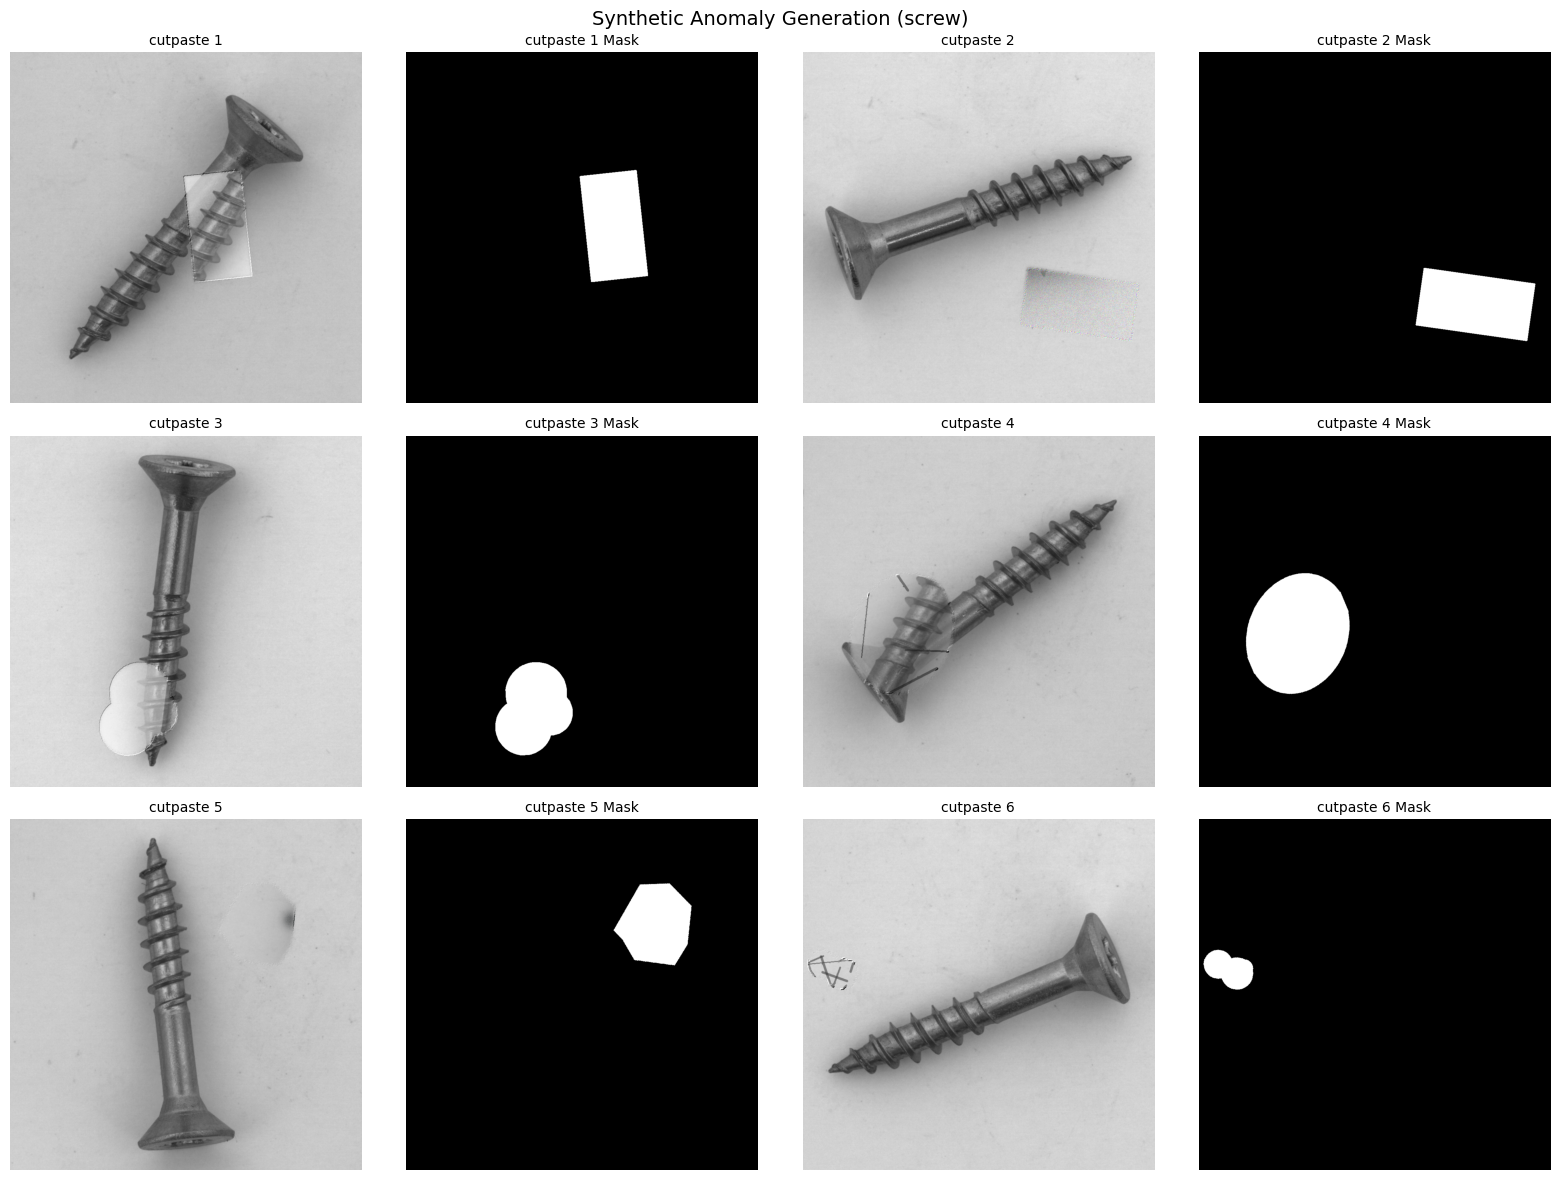

In [5]:
# Get available methods for this category
available_methods = get_methods_for_category(category)
print(f"Available synthetic methods for '{category}': {available_methods}")

# Generate synthetic anomalies
num_samples = 6
synthetic_samples = []

for sample_idx in range(num_samples):
    # Load raw image
    root_path = Path(root) / category / "train" / "good"
    image_files = sorted(list(root_path.glob("*.png")))
    raw_image = cv2.imread(str(image_files[sample_idx]))
    raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    
    # Alternate between available methods
    method_idx = sample_idx % len(available_methods)
    method_name = available_methods[method_idx]
    
    if method_name == "cutpaste":
        aug_image, aug_mask = cutpaste(raw_image.copy())
    elif method_name == "crack":
        aug_image, aug_mask = crack_anomaly(raw_image.copy())
    else:
        continue
    
    synthetic_samples.append({
        "image": aug_image,
        "mask": aug_mask,
        "method": method_name
    })

# Visualize: each row shows (image, mask) pairs
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(num_samples):
    sample = synthetic_samples[i]
    row = i // 2
    col_image = (i % 2) * 2
    col_mask = col_image + 1
    
    axes[row, col_image].imshow(sample["image"])
    axes[row, col_image].set_title(f"{sample['method']} {i+1}", fontsize=10)
    axes[row, col_image].axis("off")
    
    axes[row, col_mask].imshow(sample["mask"], cmap="gray")
    axes[row, col_mask].set_title(f"{sample['method']} {i+1} Mask", fontsize=10)
    axes[row, col_mask].axis("off")

plt.suptitle(f"Synthetic Anomaly Generation ({category})", fontsize=14)
plt.tight_layout()
plt.show()


Found 6 synthetic anomaly samples (with transforms)


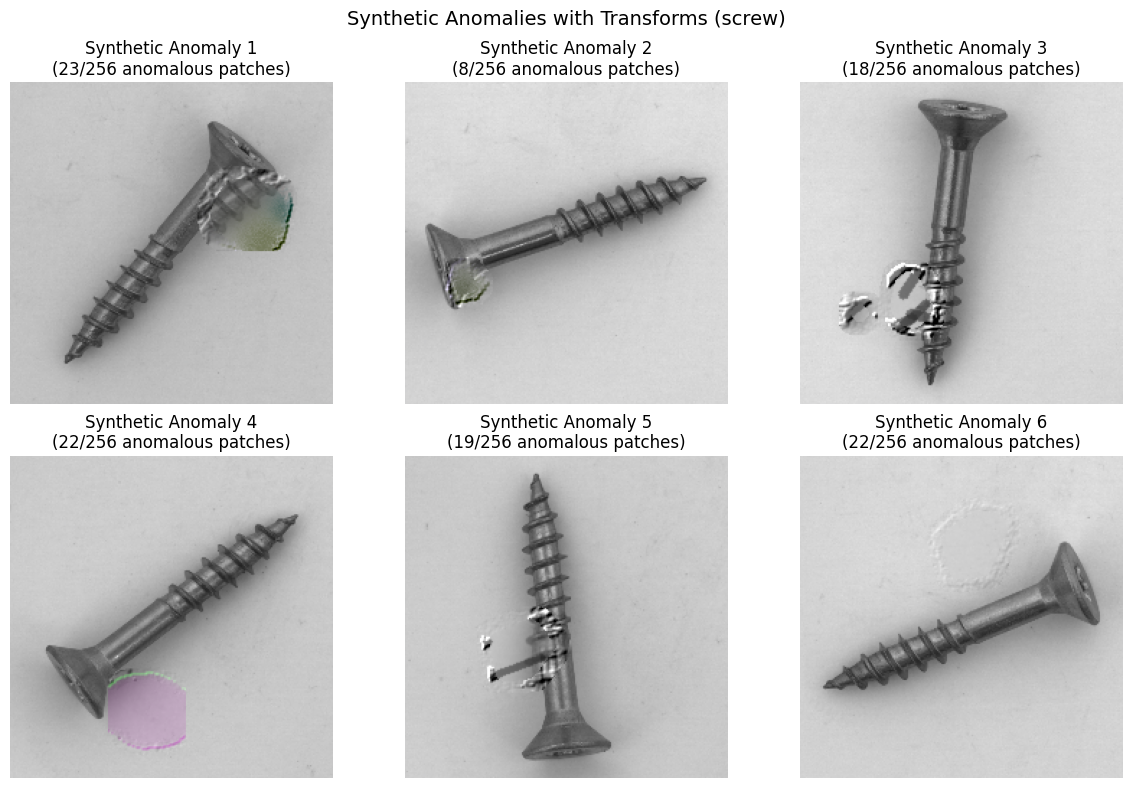

In [6]:
# Visualize synthetic anomalies from dataset (with transforms applied)
train_dataset_synthetic_viz = MVTecDataset(
    root=root,
    category=category,
    split="train",
    image_size=image_size,
    patch_size=patch_size,
    synthetic_method=available_methods[0] if available_methods else "cutpaste",
    synthetic_prob=1.0,  # 100% synthetic for visualization
)

# Collect synthetic samples
synthetic_samples_viz = []
for i in range(min(100, len(train_dataset_synthetic_viz))):
    sample = train_dataset_synthetic_viz[i]
    if sample["label"] == 1:  # Synthetic anomaly
        synthetic_samples_viz.append(sample)
    if len(synthetic_samples_viz) >= 6:
        break

print(f"Found {len(synthetic_samples_viz)} synthetic anomaly samples (with transforms)")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(min(6, len(synthetic_samples_viz))):
    sample = synthetic_samples_viz[i]
    image_np = denormalize_image(sample["image"])
    num_anomaly_patches = int(sample["patch_labels"].sum().item())
    
    axes[i].imshow(image_np)
    axes[i].set_title(f"Synthetic Anomaly {i+1}\n({num_anomaly_patches}/256 anomalous patches)")
    axes[i].axis("off")

plt.suptitle(f"Synthetic Anomalies with Transforms ({category})", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Patch-Level Label Generation

Convert pixel-level masks to patch-level labels (256 patches for 224x224 image with 14x14 patches).


cutpaste 1: 20/256 anomalous patches


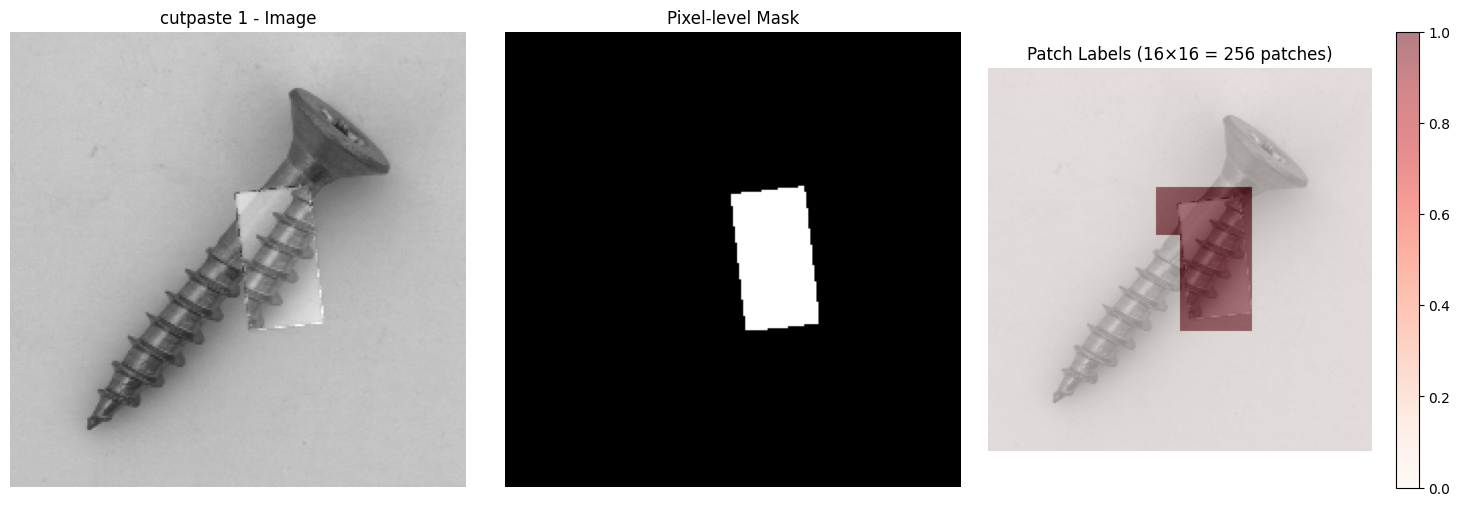

cutpaste 2: 23/256 anomalous patches


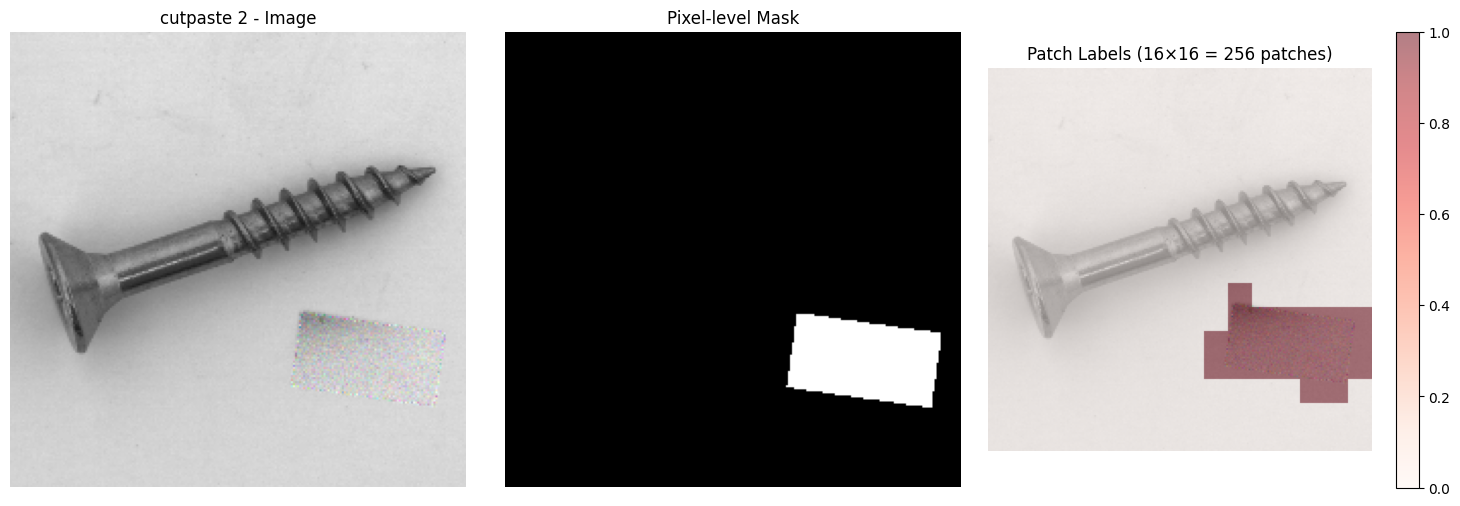

cutpaste 3: 19/256 anomalous patches


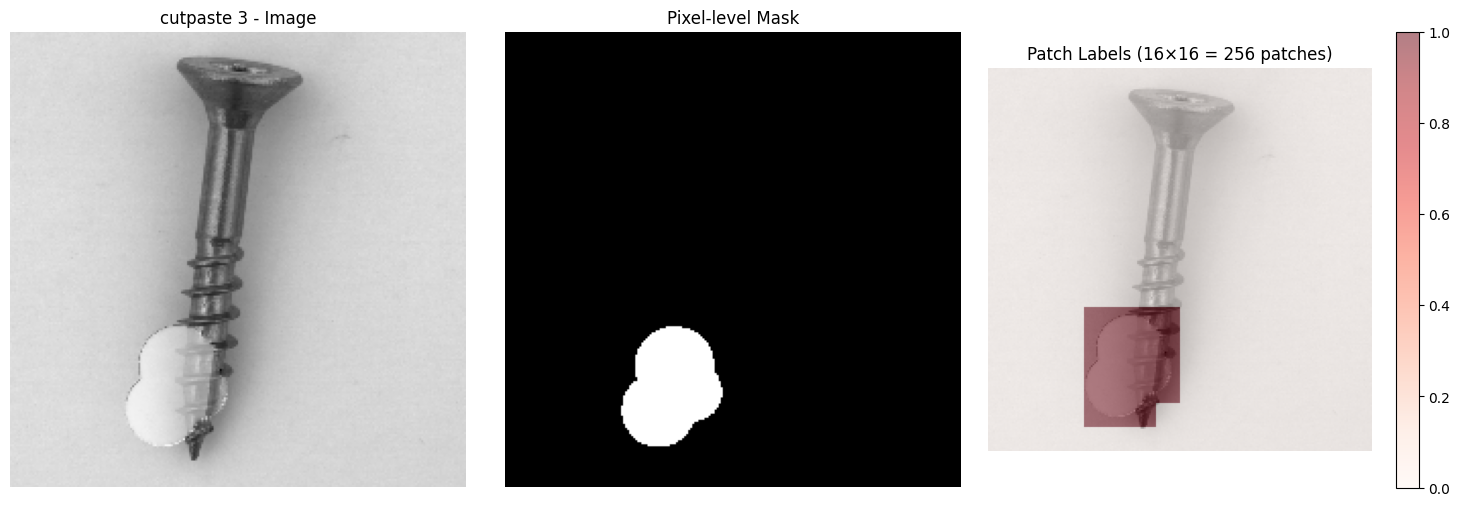

cutpaste 4: 28/256 anomalous patches


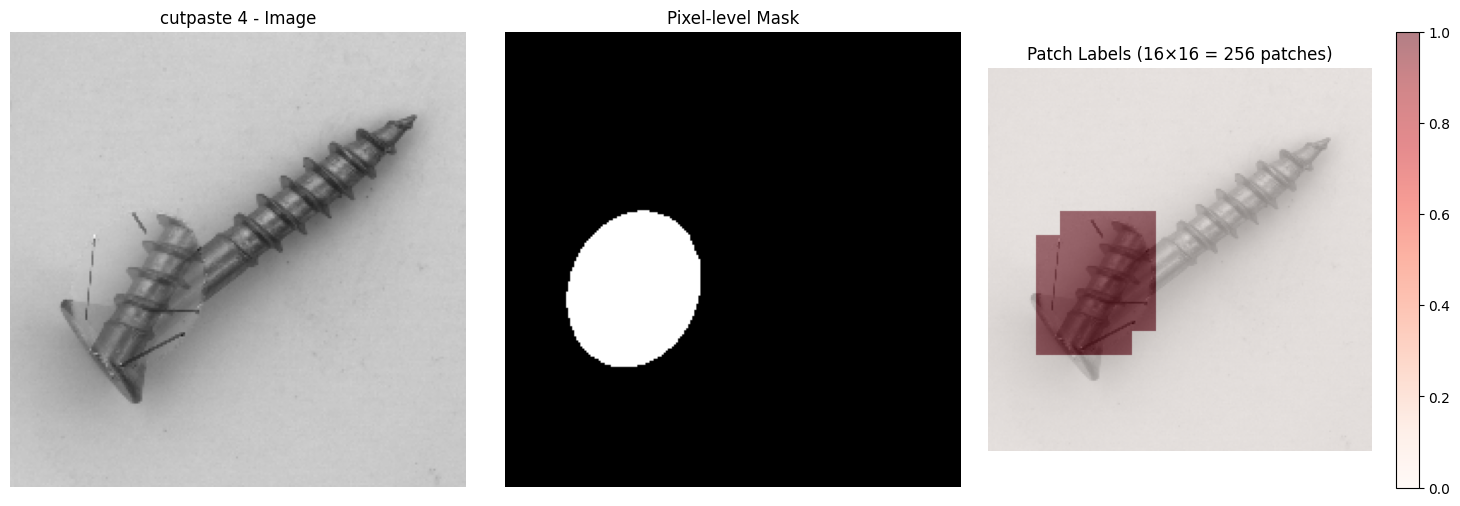

In [7]:
# Convert masks to patch-level labels
if 'synthetic_samples' in locals() and len(synthetic_samples) > 0:
    num_to_show = min(4, len(synthetic_samples))
    
    for idx in range(num_to_show):
        sample = synthetic_samples[idx]
        image = sample["image"]
        mask = sample["mask"]
        method = sample["method"]
        
        # Resize mask to match ViT input size
        mask_resized = cv2.resize(mask, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        
        # Convert to patch labels
        patch_labels = mask_to_patch_labels(mask_resized, patch_size=patch_size)
        num_anomaly_patches = int(patch_labels.sum().item())
        total_patches = len(patch_labels)
        
        print(f"{method} {idx+1}: {num_anomaly_patches}/{total_patches} anomalous patches")
        
        # Visualize
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        image_resized = cv2.resize(image, (image_size, image_size))
        
        axes[0].imshow(image_resized)
        axes[0].set_title(f"{method} {idx+1} - Image")
        axes[0].axis("off")
        
        axes[1].imshow(mask_resized, cmap="gray")
        axes[1].set_title(f"Pixel-level Mask")
        axes[1].axis("off")
        
        grid_size = int(np.sqrt(len(patch_labels)))
        patch_grid = patch_labels.reshape(grid_size, grid_size).numpy()
        patch_upsampled = cv2.resize(patch_grid, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        
        axes[2].imshow(image_resized)
        im = axes[2].imshow(patch_upsampled, alpha=0.5, cmap="Reds")
        axes[2].set_title(f"Patch Labels ({grid_size}×{grid_size} = {total_patches} patches)")
        axes[2].axis("off")
        plt.colorbar(im, ax=axes[2])
        
        plt.tight_layout()
        plt.show()
else:
    print("Please run the synthetic anomaly generation cell first")


## 6. Training Data with 80/20 Normal/Synthetic Split


Training dataset size: 320
Expected: ~256 normal, ~64 synthetic


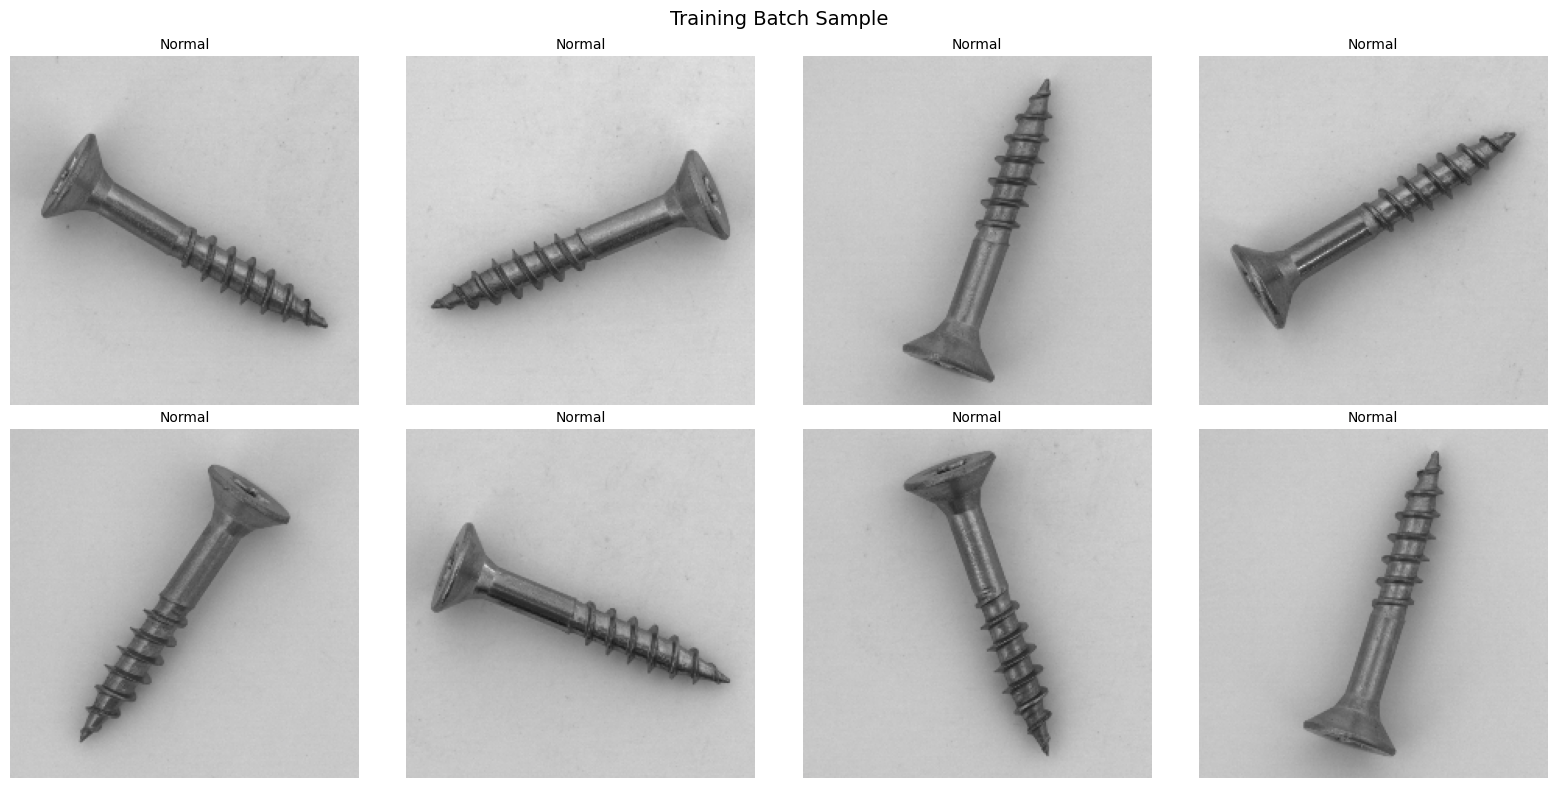


Batch statistics:
  Normal: 8/8 (100.0%)
  Synthetic: 0/8 (0.0%)


In [8]:
# Create training dataset with synthetic anomalies
train_dataset = MVTecDataset(
    root=root,
    category=category,
    split="train",
    image_size=image_size,
    patch_size=patch_size,
    synthetic_method=None,  # Auto-select based on category
    synthetic_prob=synthetic_prob,
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Expected: ~{int(len(train_dataset) * (1 - synthetic_prob))} normal, "
      f"~{int(len(train_dataset) * synthetic_prob)} synthetic")

# Sample a batch
loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
batch = next(iter(loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, len(batch["image"]))):
    image_np = denormalize_image(batch["image"][i])
    label = int(batch["label"][i])
    num_anomaly_patches = int(batch["patch_labels"][i].sum().item())
    
    axes[i].imshow(image_np)
    title = "Normal" if label == 0 else "Synthetic Anomaly"
    if label == 1:
        title += f"\n({num_anomaly_patches} anomalous patches)"
    axes[i].set_title(title, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Training Batch Sample", fontsize=14)
plt.tight_layout()
plt.show()

# Batch statistics
labels_tensor = batch["label"]
normal_count = (labels_tensor == 0).sum().item()
synthetic_count = (labels_tensor == 1).sum().item()
print(f"\nBatch statistics:")
print(f"  Normal: {normal_count}/{len(labels_tensor)} ({100*normal_count/len(labels_tensor):.1f}%)")
print(f"  Synthetic: {synthetic_count}/{len(labels_tensor)} ({100*synthetic_count/len(labels_tensor):.1f}%)")


## 7. Compare Synthetic vs Real Test Anomalies


Test dataset size: 160
Found 4 real anomaly samples
Found 4 synthetic anomaly samples


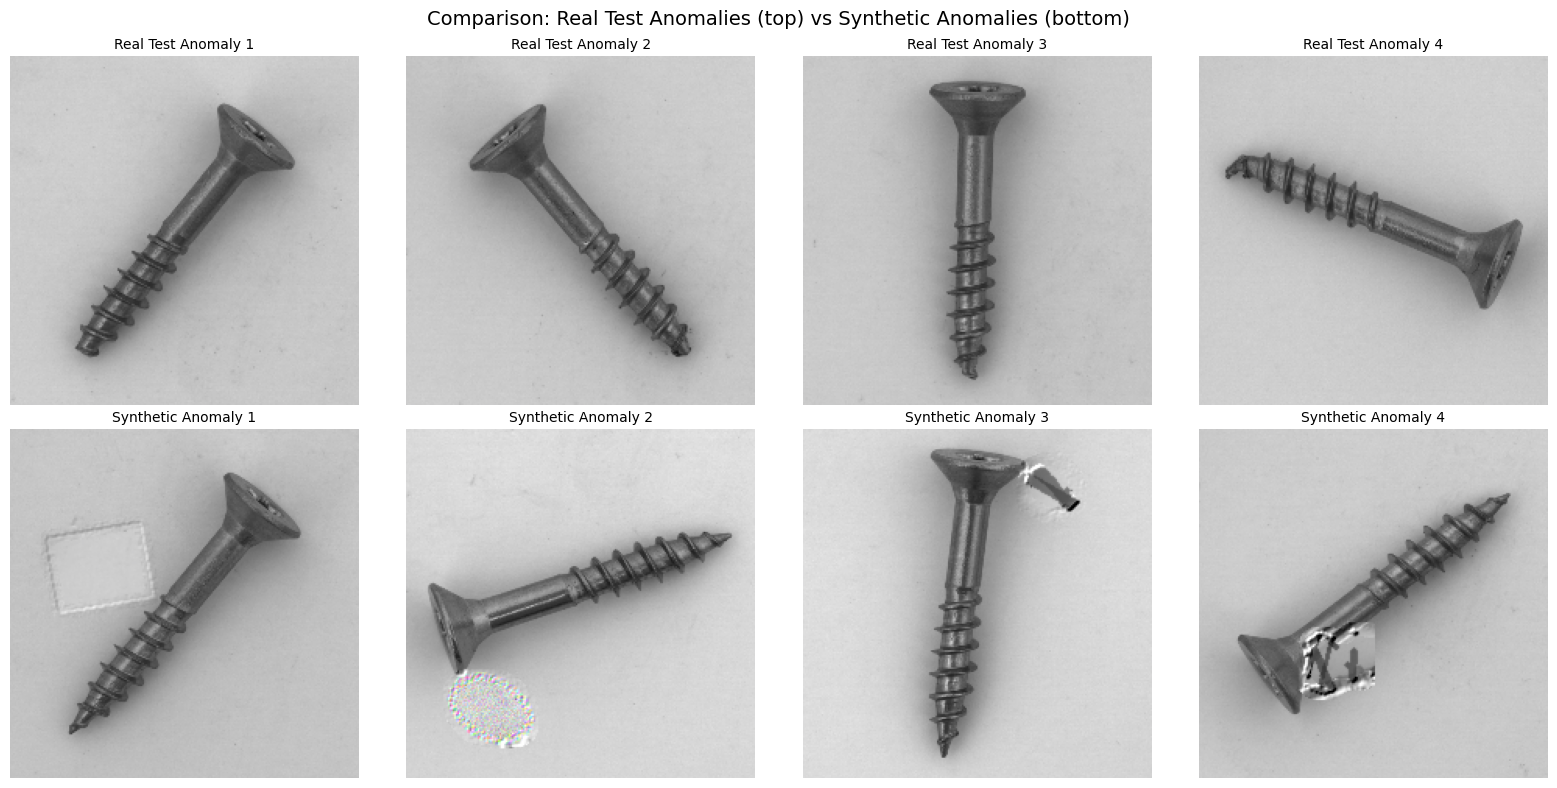


Observation: Synthetic anomalies should be diverse enough to help the model generalize.
The model learns from synthetic anomalies during training and should detect real anomalies at test time.


In [9]:
# Load test dataset (contains real anomalies)
test_dataset_comparison = MVTecDataset(
    root=root,
    category=category,
    split="test",
    image_size=image_size,
    patch_size=patch_size,
    synthetic_method=None,
    synthetic_prob=0.0,
)

print(f"Test dataset size: {len(test_dataset_comparison)}")

# Get real anomalous samples
anomalous_samples = []
for i in range(len(test_dataset_comparison)):
    sample = test_dataset_comparison[i]
    if sample["label"] == 1:
        anomalous_samples.append((i, sample))
    if len(anomalous_samples) >= 4:
        break

print(f"Found {len(anomalous_samples)} real anomaly samples")

# Create a dataset with 100% synthetic for comparison visualization
available_methods = get_methods_for_category(category)
train_dataset_synthetic_comparison = MVTecDataset(
    root=root,
    category=category,
    split="train",
    image_size=image_size,
    patch_size=patch_size,
    synthetic_method=available_methods[0] if available_methods else "cutpaste",
    synthetic_prob=1.0,  # 100% synthetic for visualization
)

# Get synthetic samples (guaranteed to be synthetic with prob=1.0)
synthetic_samples_comparison = []
for i in range(min(10, len(train_dataset_synthetic_comparison))):
    sample = train_dataset_synthetic_comparison[i]
    if sample["label"] == 1:  # Should always be 1 with prob=1.0
        synthetic_samples_comparison.append((i, sample))
    if len(synthetic_samples_comparison) >= 4:
        break

print(f"Found {len(synthetic_samples_comparison)} synthetic anomaly samples")

# Visualize comparison
if len(anomalous_samples) >= 4 and len(synthetic_samples_comparison) >= 4:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Real anomalies (top row)
    for idx, (i, sample) in enumerate(anomalous_samples[:4]):
        image_np = denormalize_image(sample["image"])
        axes[0, idx].imshow(image_np)
        axes[0, idx].set_title(f"Real Test Anomaly {idx+1}", fontsize=10)
        axes[0, idx].axis("off")
    
    # Synthetic anomalies (bottom row)
    for idx, (i, sample) in enumerate(synthetic_samples_comparison[:4]):
        image_np = denormalize_image(sample["image"])
        axes[1, idx].imshow(image_np)
        axes[1, idx].set_title(f"Synthetic Anomaly {idx+1}", fontsize=10)
        axes[1, idx].axis("off")
    
    plt.suptitle("Comparison: Real Test Anomalies (top) vs Synthetic Anomalies (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\nObservation: Synthetic anomalies should be diverse enough to help the model generalize.")
    print("The model learns from synthetic anomalies during training and should detect real anomalies at test time.")
else:
    print(f"⚠️  Not enough samples found: {len(anomalous_samples)} real, {len(synthetic_samples_comparison)} synthetic")
    print("   Need at least 4 of each for visualization.")


## 8. Model Inference and Heatmap Visualization


In [10]:
# Load model (if checkpoint exists)
import os
from models.spade import SPADE

checkpoint_dir = Path.cwd().parent / "checkpoints"
checkpoint_files = list(checkpoint_dir.glob("*.pt")) if checkpoint_dir.exists() else []

if checkpoint_files:
    # Load latest checkpoint
    latest_checkpoint = max(checkpoint_files, key=lambda p: p.stat().st_mtime)
    print(f"Loading checkpoint: {latest_checkpoint}")
    
    # Load config
    with open(Path.cwd().parent / "config" / "model.yaml") as f:
        model_cfg = yaml.safe_load(f)
    
    # Initialize model
    model = SPADE(
        blip2_model_name=model_cfg["blip2"]["model_name"],
        patch_head_hidden=model_cfg["patch_head"]["hidden_dim"],
        patch_head_dropout=model_cfg["patch_head"]["dropout"],
        llm_embed_dim=model_cfg["projection"]["output_dim"],
    ).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    else:
        model.load_state_dict(checkpoint, strict=False)
    
    model.eval()
    print("Model loaded successfully!")
    
    # Run inference on test samples
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
    test_batch = next(iter(test_loader))
    
    images = test_batch["image"].to(device)
    labels = test_batch["label"].cpu().numpy()
    
    with torch.no_grad():
        outputs = model(images)
        patch_logits = outputs["patch_logits"]  # (B, N_patches)
        patch_probs = torch.sigmoid(patch_logits).cpu().numpy()
    
    # Visualize heatmaps
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i in range(min(4, len(images))):
        # Original image
        image_np = images[i].permute(1, 2, 0).cpu().numpy()
        # Denormalize for visualization (CLIP normalization stats)
        mean = np.array([0.48145466, 0.4578275, 0.40821073])
        std = np.array([0.26862954, 0.26130258, 0.27577711])
        image_np = image_np * std + mean
        image_np = np.clip(image_np, 0, 1)
        image_np = np.clip(image_np, 0, 1)
        
        # Heatmap
        heatmap = patches_to_heatmap(
            torch.tensor(patch_probs[i]),
            image_size=image_size,
            patch_size=14,
        )
        
        # Overlay
        overlay = overlay_heatmap((image_np * 255).astype(np.uint8), heatmap, alpha=0.4)
        
        # Original
        axes[0, i].imshow(image_np)
        axes[0, i].set_title(f"Image {i+1} (Label: {'Anomaly' if labels[i] == 1 else 'Normal'})")
        axes[0, i].axis("off")
        
        # Heatmap overlay
        axes[1, i].imshow(overlay / 255.0)
        axes[1, i].set_title(f"Anomaly Heatmap (Max: {patch_probs[i].max():.3f})")
        axes[1, i].axis("off")
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No checkpoint found. Train the model first using train.py")


⚠ No checkpoint found at /home/owais/spade/checkpoints/screw/spade_best.pt
  Train the model first: python train.py


## 9. Detailed Patch-Level Analysis


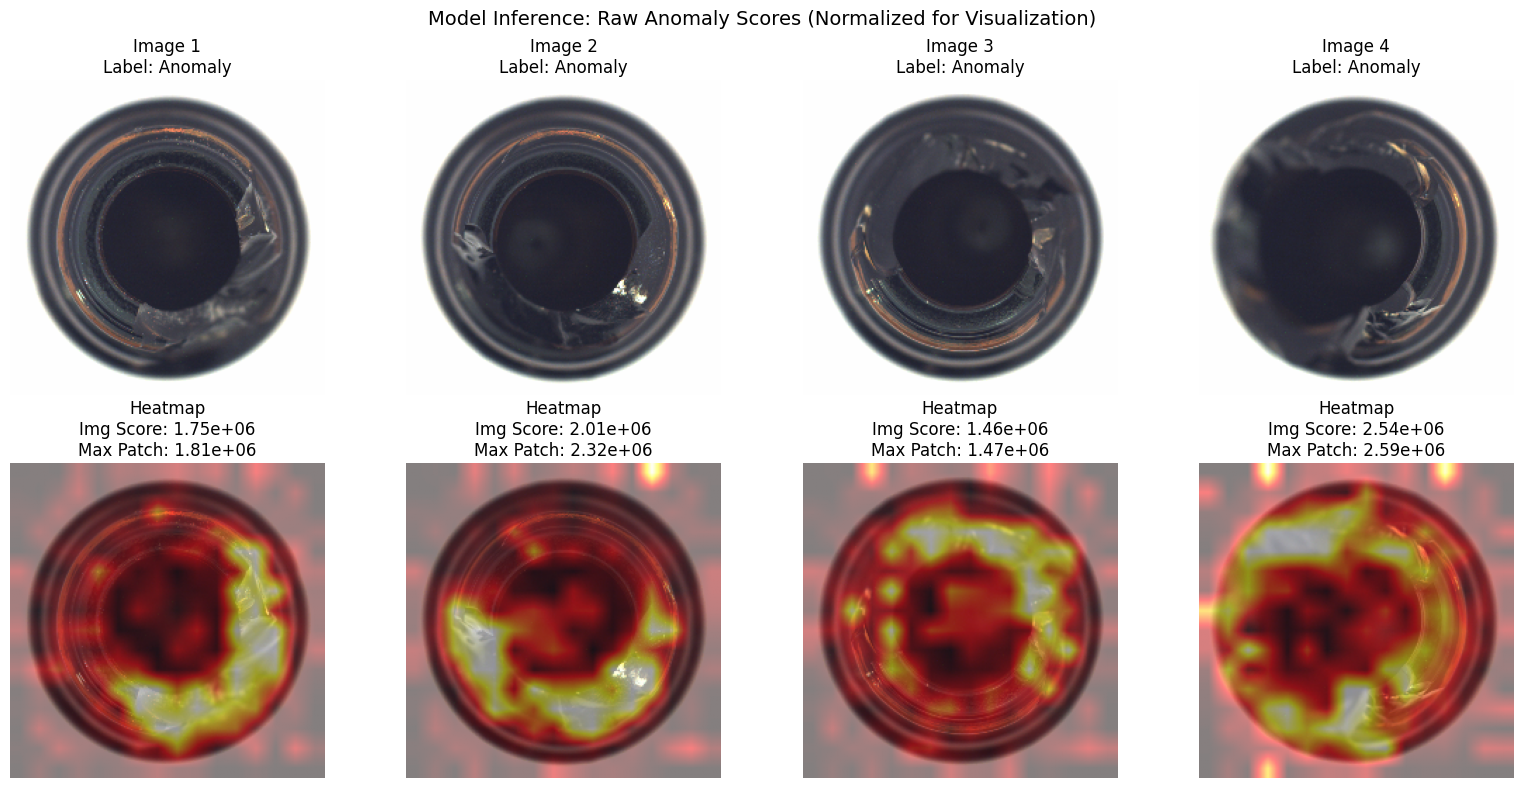


Note: Scores shown are RAW Mahalanobis distances (not probabilities).
For pixel AUROC, we use raw scores without normalization.


In [12]:
# Run inference on test samples
if model is not None:
    # Load test dataset
    test_dataset = MVTecDataset(
        root=root,
        category=category,
        split="test",
        image_size=image_size,
        patch_size=patch_size,
        synthetic_method=None,
        synthetic_prob=0.0,
    )
    
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)
    test_batch = next(iter(test_loader))
    
    images = test_batch["image"].to(device)
    labels = test_batch["label"].cpu().numpy()
    
    with torch.no_grad():
        outputs = model(images)  # No update_stats in inference
        patch_scores = outputs["patch_scores"]  # (B, 256) - RAW scores, not probabilities!
        image_scores = model.get_image_score(patch_scores)  # (B,) - aggregated scores
    
    # Visualize heatmaps (normalize for visualization)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i in range(min(4, len(images))):
        image_np = denormalize_image(images[i])
        
        # Normalize patch scores for visualization (percentile-based)
        patch_scores_np = patch_scores[i].detach().cpu().numpy()
        p5, p95 = np.percentile(patch_scores_np, [5, 95])
        patch_scores_clipped = np.clip(patch_scores_np, p5, p95)
        if p95 - p5 > 1e-8:
            patch_scores_normalized = (patch_scores_clipped - p5) / (p95 - p5)
        else:
            patch_scores_normalized = np.zeros_like(patch_scores_clipped)
        
        # Create heatmap
        heatmap = patches_to_heatmap(
            torch.from_numpy(patch_scores_normalized),
            image_size=image_size,
            patch_size=patch_size,
            normalize=False,  # Already normalized above
        )
        
        # Overlay
        overlay = overlay_heatmap((image_np * 255).astype(np.uint8), heatmap, alpha=0.5)
        
        # Original
        axes[0, i].imshow(image_np)
        label_str = "Anomaly" if labels[i] == 1 else "Normal"
        axes[0, i].set_title(f"Image {i+1}\nLabel: {label_str}")
        axes[0, i].axis("off")
        
        # Heatmap overlay
        axes[1, i].imshow(overlay / 255.0)
        img_score = image_scores[i].item()
        max_patch_score = patch_scores[i].max().item()
        axes[1, i].set_title(f"Heatmap\nImg Score: {img_score:.2e}\nMax Patch: {max_patch_score:.2e}")
        axes[1, i].axis("off")
    
    plt.suptitle("Model Inference: Raw Anomaly Scores (Normalized for Visualization)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\nNote: Scores shown are RAW Mahalanobis distances (not probabilities).")
    print("For pixel AUROC, we use raw scores without normalization.")
else:
    print("Model not loaded. Train first or check checkpoint path.")


## 10. Detailed Patch-Level Analysis

Compare predictions vs ground truth at patch level.


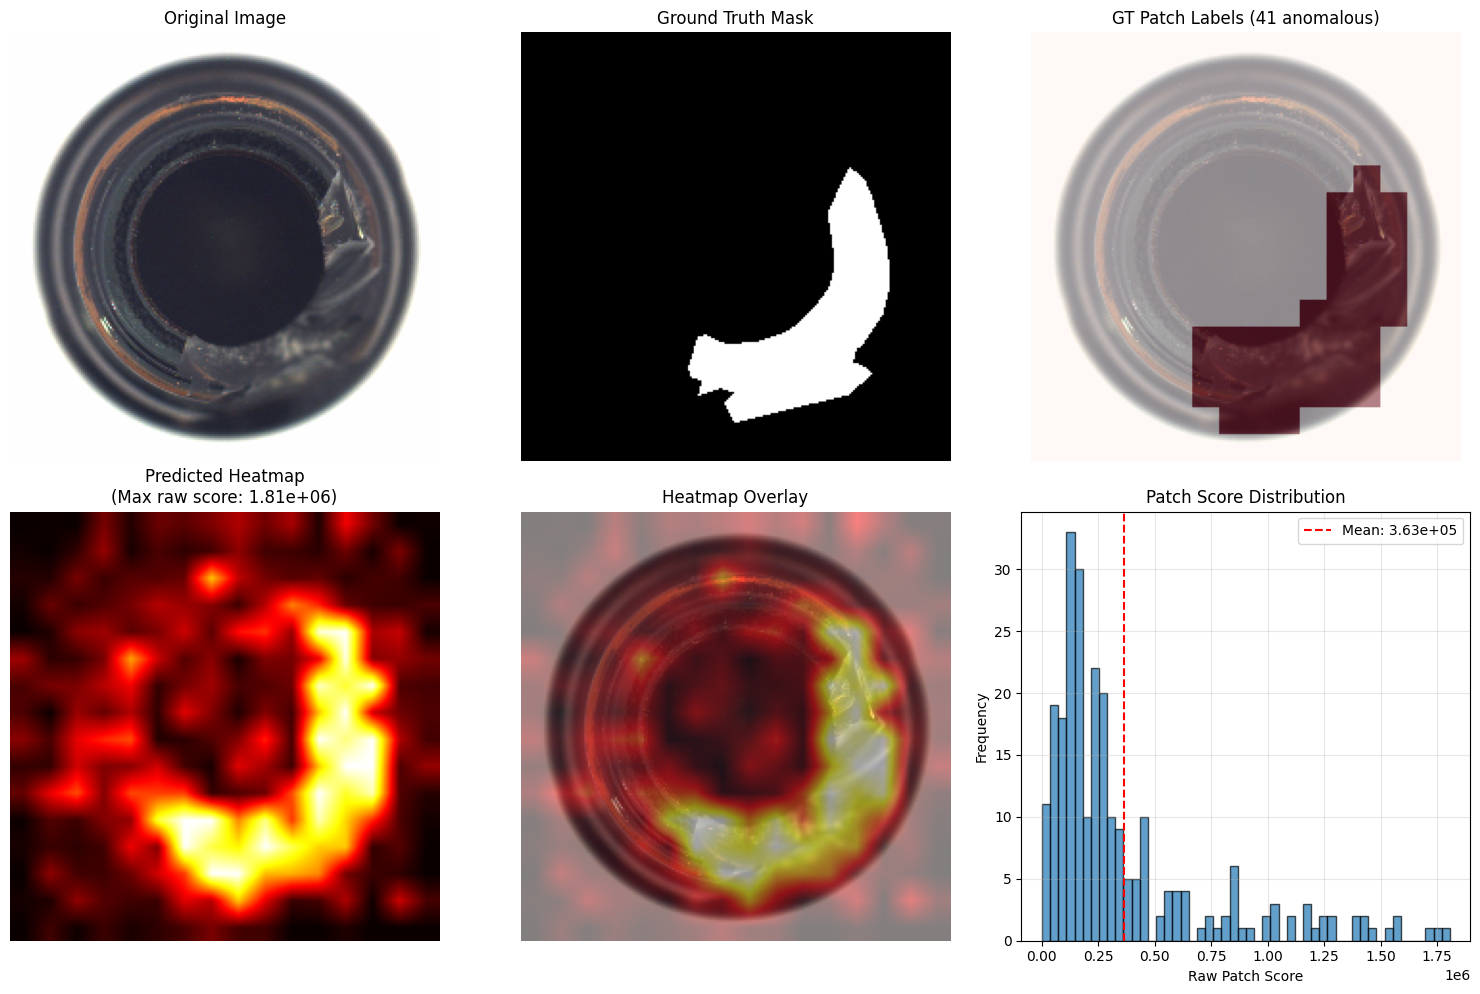


Patch-level Statistics:
  Ground truth anomalous patches: 41/256
  Raw patch scores:
    Min: 6.95e+02
    Max: 1.81e+06
    Mean: 3.63e+05
    Std: 3.79e+05
  Image-level score: 1.75e+06


In [13]:
# Detailed patch-level analysis
if model is not None:
    # Get an anomalous test sample
    for i in range(len(test_dataset)):
        sample = test_dataset[i]
        if sample["label"] == 1:
            break
    
    # Run inference
    image = sample["image"].unsqueeze(0).to(device)
    gt_mask = sample["mask"]
    if isinstance(gt_mask, torch.Tensor):
        gt_mask = gt_mask.cpu().numpy()
    
    gt_patch_labels = sample["patch_labels"].cpu().numpy()
    
    with torch.no_grad():
        outputs = model(image)
        patch_scores = outputs["patch_scores"][0]  # (256,) - RAW scores
    
    # Normalize for visualization
    patch_scores_np = patch_scores.detach().cpu().numpy()
    p5, p95 = np.percentile(patch_scores_np, [5, 95])
    patch_scores_clipped = np.clip(patch_scores_np, p5, p95)
    if p95 - p5 > 1e-8:
        patch_scores_normalized = (patch_scores_clipped - p5) / (p95 - p5)
    else:
        patch_scores_normalized = np.zeros_like(patch_scores_clipped)
    
    # Visualize
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    image_np = denormalize_image(sample["image"])
    
    # Original image
    axes[0, 0].imshow(image_np)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")
    
    # Ground truth mask
    axes[0, 1].imshow(gt_mask, cmap="gray")
    axes[0, 1].set_title("Ground Truth Mask")
    axes[0, 1].axis("off")
    
    # Ground truth patch labels
    grid_size = int(np.sqrt(len(gt_patch_labels)))
    gt_patch_grid = gt_patch_labels.reshape(grid_size, grid_size)
    gt_patch_upsampled = cv2.resize(gt_patch_grid, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
    axes[0, 2].imshow(image_np)
    axes[0, 2].imshow(gt_patch_upsampled, alpha=0.5, cmap="Reds")
    axes[0, 2].set_title(f"GT Patch Labels ({gt_patch_labels.sum():.0f} anomalous)")
    axes[0, 2].axis("off")
    
    # Predicted heatmap (normalized for visualization)
    heatmap = patches_to_heatmap(
        torch.from_numpy(patch_scores_normalized),
        image_size=image_size,
        patch_size=patch_size,
        normalize=False,
    )
    axes[1, 0].imshow(heatmap, cmap="hot")
    axes[1, 0].set_title(f"Predicted Heatmap\n(Max raw score: {patch_scores.max().item():.2e})")
    axes[1, 0].axis("off")
    
    # Overlay
    overlay = overlay_heatmap((image_np * 255).astype(np.uint8), heatmap, alpha=0.5)
    axes[1, 1].imshow(overlay / 255.0)
    axes[1, 1].set_title("Heatmap Overlay")
    axes[1, 1].axis("off")
    
    # Score distribution
    axes[1, 2].hist(patch_scores_np, bins=50, alpha=0.7, edgecolor='black')
    axes[1, 2].axvline(patch_scores_np.mean(), color='r', linestyle='--', label=f'Mean: {patch_scores_np.mean():.2e}')
    axes[1, 2].set_xlabel("Raw Patch Score")
    axes[1, 2].set_ylabel("Frequency")
    axes[1, 2].set_title("Patch Score Distribution")
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nPatch-level Statistics:")
    print(f"  Ground truth anomalous patches: {gt_patch_labels.sum():.0f}/{len(gt_patch_labels)}")
    print(f"  Raw patch scores:")
    print(f"    Min: {patch_scores_np.min():.2e}")
    print(f"    Max: {patch_scores_np.max():.2e}")
    print(f"    Mean: {patch_scores_np.mean():.2e}")
    print(f"    Std: {patch_scores_np.std():.2e}")
    print(f"  Image-level score: {model.get_image_score(patch_scores.unsqueeze(0)).item():.2e}")
else:
    print("Model not loaded.")


In [14]:
# Analyze training data distribution
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

normal_count = 0
synthetic_count = 0
total_patches_normal = 0
total_patches_synthetic = 0

for batch in train_loader:
    labels = batch["label"].numpy()
    patch_labels = batch["patch_labels"]
    
    normal_mask = labels == 0
    synthetic_mask = labels == 1
    
    normal_count += normal_mask.sum()
    synthetic_count += synthetic_mask.sum()
    
    total_patches_normal += patch_labels[normal_mask].sum().item()
    total_patches_synthetic += patch_labels[synthetic_mask].sum().item()

print("=" * 60)
print("TRAINING DATA STATISTICS")
print("=" * 60)
print(f"Total samples: {len(train_dataset)}")
print(f"Normal samples: {normal_count} ({100*normal_count/len(train_dataset):.1f}%)")
print(f"Synthetic anomaly samples: {synthetic_count} ({100*synthetic_count/len(train_dataset):.1f}%)")
print(f"\nPatch-level:")
print(f"  Total anomalous patches (synthetic): {total_patches_synthetic}")
print(f"  Average anomalous patches per synthetic sample: {total_patches_synthetic/max(synthetic_count, 1):.1f}")
print(f"\nExpected ratio: ~{100*(1-synthetic_prob):.0f}% normal / ~{100*synthetic_prob:.0f}% synthetic")
print("=" * 60)


TRAINING DATA STATISTICS
Total samples: 209
Normal samples: 209 (100.0%)
Synthetic anomaly samples: 0 (0.0%)

Patch-level:
  Total anomalous patches (synthetic): 0.0
  Average anomalous patches per synthetic sample: 0.0

Expected ratio: ~80% normal / ~20% synthetic
